In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ratings = pd.read_parquet("../data/processed/ratings_clean.parquet")
movies = pd.read_parquet("../data/processed/movies_enriched.parquet")

print(ratings.shape)
ratings.head()

(15248980, 4)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


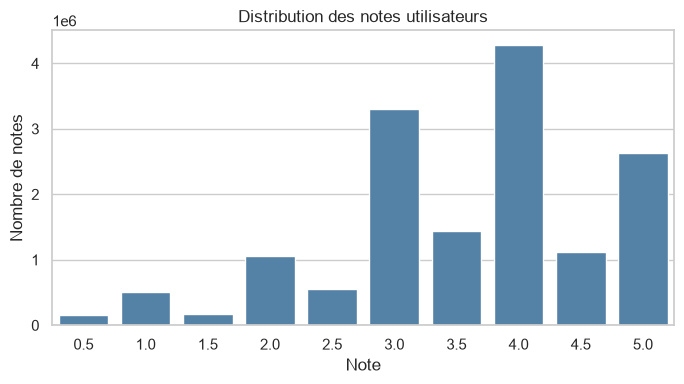

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x="rating", data=ratings, color="steelblue")
plt.title("Distribution des notes utilisateurs")
plt.xlabel("Note")
plt.ylabel("Nombre de notes")
plt.tight_layout()
plt.show()

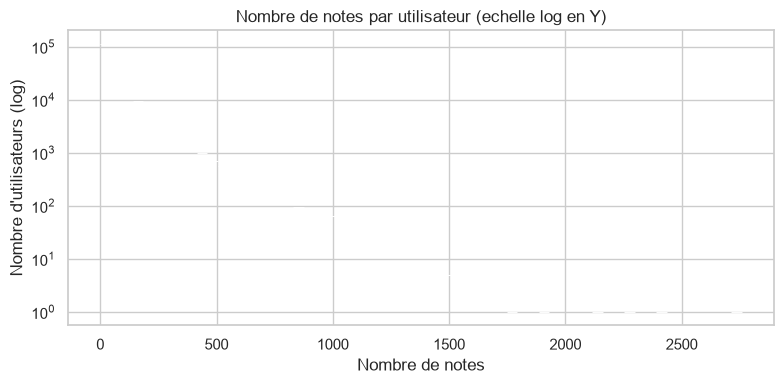

Notes par utilisateur -- median: 38, moyenne: 76.3, max: 2759


In [4]:
ratings_per_user = ratings.groupby("userId").size()

plt.figure(figsize=(8, 4))
sns.histplot(ratings_per_user, bins=60, log_scale=(False, True))
plt.title("Nombre de notes par utilisateur (echelle log en Y)")
plt.xlabel("Nombre de notes")
plt.ylabel("Nombre d'utilisateurs (log)")
plt.tight_layout()
plt.show()

print(f"Notes par utilisateur -- median: {ratings_per_user.median():.0f}, "
      f"moyenne: {ratings_per_user.mean():.1f}, max: {ratings_per_user.max()}")

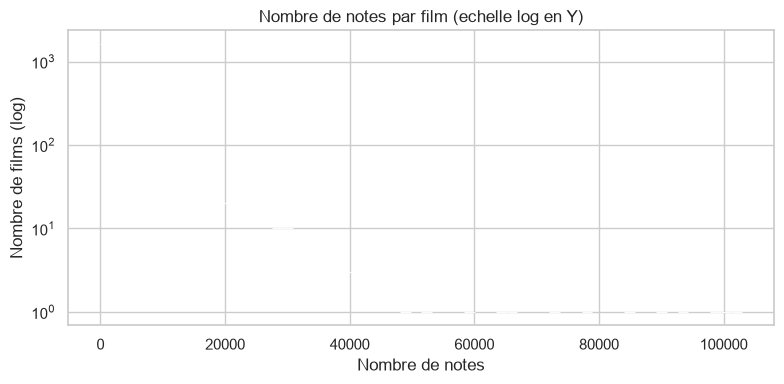

In [5]:
ratings_per_movie = ratings.groupby("movieId").size()

plt.figure(figsize=(8, 4))
sns.histplot(ratings_per_movie, bins=60, log_scale=(False, True), color="darkorange")
plt.title("Nombre de notes par film (echelle log en Y)")
plt.xlabel("Nombre de notes")
plt.ylabel("Nombre de films (log)")
plt.tight_layout()
plt.show()

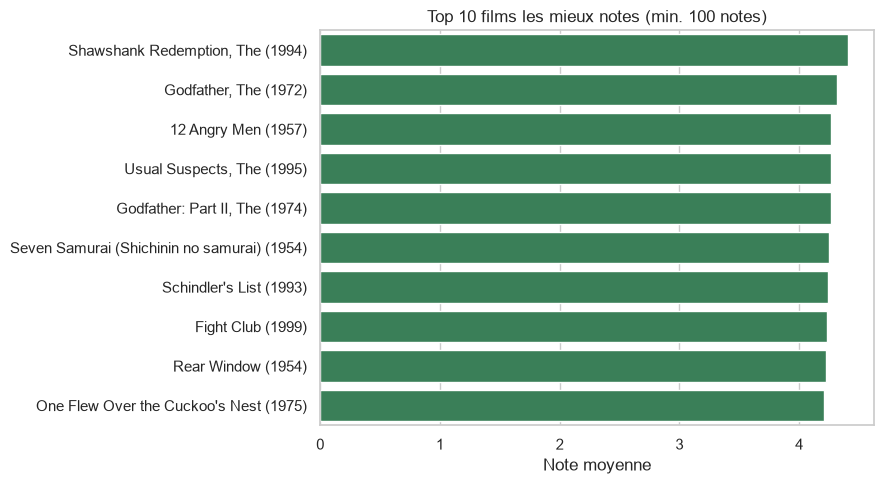

In [ ]:
movie_stats = (
    ratings.groupby("movieId")
    .agg(avg_rating=("rating", "mean"), n_ratings=("rating", "count"))
    .merge(movies[["movieId", "title_movielens"]], on="movieId")
)

top_rated = movie_stats[movie_stats["n_ratings"] > 100].sort_values(
    "avg_rating", ascending=False
).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x="avg_rating", y="title_movielens", data=top_rated, color="seagreen")
plt.title("Top 10 films les mieux notes (min. 100 notes)")
plt.xlabel("Note moyenne")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [7]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
n_ratings_total = len(ratings)
sparsity = 1 - (n_ratings_total / (n_users * n_movies))

print(f"Utilisateurs: {n_users}, Films: {n_movies}, Notes: {n_ratings_total}")
print(f"Sparsite de la matrice user-item: {sparsity:.4%}")

Utilisateurs: 199827, Films: 3002, Notes: 15248980
Sparsite de la matrice user-item: 97.4580%
